# Microsoft Datathon – TWP90 Early Warning System

Notebook ini menyusun alur analisis dari data mentah menjadi model prediksi **twp90_pct**.

## Alur kerja

1. Memuat data panel yang sudah diproses
2. Mengecek ringkasan dan kualitas data
3. Menangani nilai hilang dan melakukan smoothing
4. Membuat fitur lag berbasis waktu
5. Melatih model prediksi dan meninjau hasilnya
6. Menunjukkan visualisasi hubungan antar variabel

In [36]:
from pathlib import Path
import pandas as pd

# Step 1 — Load the prepared panel dataset from the local workspace.
# We use a relative path so the notebook works on this machine without Colab paths.
data_path = Path('model_panel.csv')
if not data_path.exists():
    raise FileNotFoundError(f"Dataset not found: {data_path.resolve()}")

df = pd.read_csv(data_path)
print(f"Data loaded successfully from {data_path}.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Here are the first 5 rows:")
display(df.head())

Data loaded successfully from model_panel.csv.
Shape: 1,920 rows × 16 columns
Here are the first 5 rows:


,provinsi_id,nama_provinsi,tanggal,tahun,bulan,twp90_pct,x1_bi_rate_pct,x2_inflasi_yoy,x3_pdrb_per_kapita,x4_tpt_pct,x5_penetrasi_internet_pct,x6_tabungan_miliar,x7_jumlah_kc_bank,x8_ldr_pct,x9_npl_ratio,x10_rasio_umkm
0,1,Banten,2021-01-01,2021,1,0.0155,3.75,0.00373,55383000.0,NaN,NaN,224668.73,104.0,0.7589,0.0226,0.2728
1,1,Banten,2021-02-01,2021,2,0.0163,3.50,0.00233,55383000.0,9.01,NaN,224668.73,104.0,0.7589,0.0226,0.2728
2,1,Banten,2021-03-01,2021,3,0.0140,3.50,0.00140,55383000.0,NaN,NaN,224668.73,104.0,0.7589,0.0226,0.2728
3,1,Banten,2021-04-01,2021,4,0.0130,3.50,0.00187,55383000.0,NaN,NaN,224668.73,104.0,0.7589,0.0226,0.2728
4,1,Banten,2021-05-01,2021,5,0.0131,3.50,0.00257,55383000.0,NaN,NaN,224668.73,104.0,0.7589,0.0226,0.2728


## 1. Memuat data

Langkah pertama adalah membaca file panel yang sudah dibentuk sebelumnya.
Di sini kita memastikan file ada, lalu menampilkan beberapa baris awal untuk verifikasi cepat.

In [37]:
print("\nHere is a basic description of the data:")
display(df.describe())


Here is a basic description of the data:


,provinsi_id,tahun,bulan,twp90_pct,x1_bi_rate_pct,x2_inflasi_yoy,x3_pdrb_per_kapita,x4_tpt_pct,x5_penetrasi_internet_pct,x6_tabungan_miliar,x7_jumlah_kc_bank,x8_ldr_pct,x9_npl_ratio,x10_rasio_umkm
count,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1920.000000,1.920000e+03,320.000000,1536.000000,1.860000e+03,1860.000000,1860.000000,1860.000000,1860.000000
mean,16.500000,2023.000000,6.500000,0.019550,4.945833,0.010464,7.897959e+07,4.839375,0.762923,2.288011e+05,107.767742,1.138262,0.023986,0.390981
std,9.235498,1.414582,3.452952,0.009499,1.085305,0.012058,6.090782e+07,1.532771,0.074695,6.187701e+05,113.420760,0.453559,0.008731,0.170729
min,1.000000,2021.000000,1.000000,0.003200,3.500000,-0.015200,2.055500e+07,1.490000,0.530300,5.701060e+03,16.000000,0.567600,0.010700,0.037200
25%,8.750000,2022.000000,3.750000,0.013500,3.500000,0.001400,4.523000e+07,3.730000,0.718100,2.980327e+04,45.000000,0.818900,0.017400,0.301900
50%,16.500000,2023.000000,6.500000,0.018100,5.500000,0.006250,5.992650e+07,4.525000,0.767500,5.387055e+04,62.000000,1.054900,0.021800,0.378400
75%,24.250000,2024.000000,9.250000,0.023700,5.812500,0.018925,7.588350e+07,5.860000,0.810450,1.275911e+05,98.000000,1.275200,0.028300,0.454100
max,32.000000,2025.000000,12.000000,0.115800,6.250000,0.067100,3.676870e+08,10.120000,0.913500,3.893791e+06,456.000000,2.924800,0.053800,0.921800


## 2. Ringkasan statistik dasar

Setelah data dimuat, kita melihat statistik deskriptif awal untuk mengenali skala, sebaran, dan potensi anomali pada setiap variabel numerik.

In [38]:
# Filter out data for years 2021 and below
# This keeps the analysis focused on the period used for the early warning model.
df_filtered = df[df['tahun'] > 2021].copy()

print("Data after filtering for years > 2021:")
display(df_filtered.describe())

Data after filtering for years > 2021:


,provinsi_id,tahun,bulan,twp90_pct,x1_bi_rate_pct,x2_inflasi_yoy,x3_pdrb_per_kapita,x4_tpt_pct,x5_penetrasi_internet_pct,x6_tabungan_miliar,x7_jumlah_kc_bank,x8_ldr_pct,x9_npl_ratio,x10_rasio_umkm
count,1536.0000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1.536000e+03,256.000000,1536.000000,1.488000e+03,1488.000000,1488.000000,1488.000000,1488.000000
mean,16.5000,2023.500000,6.500000,0.020813,5.302083,0.012611,8.384526e+07,4.663437,0.762923,2.345599e+05,106.677419,1.156613,0.023628,0.403445
std,9.2361,1.118398,3.453177,0.009762,0.914535,0.012461,6.455879e+07,1.415058,0.074695,6.344721e+05,112.379309,0.460186,0.008219,0.181319
min,1.0000,2022.000000,1.000000,0.004400,3.500000,-0.015200,2.165800e+07,1.490000,0.530300,5.701060e+03,17.000000,0.592000,0.010700,0.037200
25%,8.7500,2022.750000,3.750000,0.014400,4.750000,0.002500,4.813350e+07,3.667500,0.718100,3.072825e+04,44.000000,0.834350,0.017400,0.305325
50%,16.5000,2023.500000,6.500000,0.019100,5.750000,0.009750,6.420050e+07,4.330000,0.767500,5.585760e+04,61.000000,1.064850,0.021650,0.388050
75%,24.2500,2024.250000,9.250000,0.025100,6.000000,0.022200,7.889100e+07,5.750000,0.810450,1.337809e+05,97.250000,1.290300,0.028100,0.476775
max,32.0000,2025.000000,12.000000,0.115800,6.250000,0.067100,3.676870e+08,8.530000,0.913500,3.893791e+06,451.000000,2.924800,0.053800,0.921800


## 3. Menyaring periode analisis

Pada bagian ini data difokuskan ke tahun yang relevan untuk modeling. Nilai tahun di atas 2021 dipakai agar analisis dan model lebih konsisten dengan horizon prediksi.

In [39]:
missing_x4_tpt_pct = df_filtered['x4_tpt_pct'].isnull().sum()
print(f"Number of missing values in 'x4_tpt_pct': {missing_x4_tpt_pct}")

Number of missing values in 'x4_tpt_pct': 1280


In [40]:
# Convert 'tanggal' to datetime so the time order is handled correctly.
df_filtered['tanggal'] = pd.to_datetime(df_filtered['tanggal'])

# Sort by province and date to ensure the fill operation follows the time sequence.
df_filtered = df_filtered.sort_values(by=['provinsi_id', 'tanggal']).reset_index(drop=True)

# TPT (x4_tpt_pct) is reported with a different frequency, so we fill short gaps
# within each province using forward-fill followed by a one-step backward-fill.
df_filtered['x4_tpt_pct'] = df_filtered.groupby('provinsi_id')['x4_tpt_pct'].ffill(limit=5)
df_filtered['x4_tpt_pct'] = df_filtered.groupby('provinsi_id')['x4_tpt_pct'].bfill(limit=1)

print("DataFrame after 5-month forward fill and 1-month backward fill for 'x4_tpt_pct':")
display(df_filtered[df_filtered['provinsi_id'] == 1][['tanggal', 'x4_tpt_pct']].head(12))

DataFrame after 5-month forward fill and 1-month backward fill for 'x4_tpt_pct':


,tanggal,x4_tpt_pct
0,2022-01-01,8.53
1,2022-02-01,8.53
2,2022-03-01,8.53
3,2022-04-01,8.53
4,2022-05-01,8.53
5,2022-06-01,8.53
6,2022-07-01,8.53
7,2022-08-01,8.09
8,2022-09-01,8.09
9,2022-10-01,8.09


In [41]:
df_filtered.describe()

,provinsi_id,tanggal,tahun,bulan,twp90_pct,x1_bi_rate_pct,x2_inflasi_yoy,x3_pdrb_per_kapita,x4_tpt_pct,x5_penetrasi_internet_pct,x6_tabungan_miliar,x7_jumlah_kc_bank,x8_ldr_pct,x9_npl_ratio,x10_rasio_umkm
count,1536.0000,1536,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1.536000e+03,1536.000000,1536.000000,1.488000e+03,1488.000000,1488.000000,1488.000000,1488.000000
mean,16.5000,2023-12-16 11:00:00,2023.500000,6.500000,0.020813,5.302083,0.012611,8.384526e+07,4.678223,0.762923,2.345599e+05,106.677419,1.156613,0.023628,0.403445
min,1.0000,2022-01-01 00:00:00,2022.000000,1.000000,0.004400,3.500000,-0.015200,2.165800e+07,1.490000,0.530300,5.701060e+03,17.000000,0.592000,0.010700,0.037200
25%,8.7500,2022-12-24 06:00:00,2022.750000,3.750000,0.014400,4.750000,0.002500,4.813350e+07,3.670000,0.718100,3.072825e+04,44.000000,0.834350,0.017400,0.305325
50%,16.5000,2023-12-16 12:00:00,2023.500000,6.500000,0.019100,5.750000,0.009750,6.420050e+07,4.330000,0.767500,5.585760e+04,61.000000,1.064850,0.021650,0.388050
75%,24.2500,2024-12-08 18:00:00,2024.250000,9.250000,0.025100,6.000000,0.022200,7.889100e+07,5.750000,0.810450,1.337809e+05,97.250000,1.290300,0.028100,0.476775
max,32.0000,2025-12-01 00:00:00,2025.000000,12.000000,0.115800,6.250000,0.067100,3.676870e+08,8.530000,0.913500,3.893791e+06,451.000000,2.924800,0.053800,0.921800
std,9.2361,NaN,1.118398,3.453177,0.009762,0.914535,0.012461,6.455879e+07,1.419424,0.074695,6.344721e+05,112.379309,0.460186,0.008219,0.181319


In [42]:
cols_to_check = ['x6_tabungan_miliar', 'x7_jumlah_kc_bank', 'x8_ldr_pct', 'x9_npl_ratio', 'x10_rasio_umkm']

for col in cols_to_check:
    missing_data = df_filtered[df_filtered[col].isnull()]
    if not missing_data.empty:
        print(f"\n--- Missing values for column: {col} ---")
        # Group by provinsi_id and nama_provinsi to find the date range of missing values
        missing_summary = missing_data.groupby(['provinsi_id', 'nama_provinsi'])['tanggal'].agg(['min', 'max', 'count']).reset_index()
        missing_summary = missing_summary.rename(columns={'min': 'start_tanggal_missing', 'max': 'end_tanggal_missing', 'count': 'num_missing_entries'})
        display(missing_summary)
    else:
        print(f"\nNo missing values found for column: {col}")


--- Missing values for column: x6_tabungan_miliar ---


,provinsi_id,nama_provinsi,start_tanggal_missing,end_tanggal_missing,num_missing_entries
0,19,Kalimantan Utara,2022-01-01,2025-12-01,48



--- Missing values for column: x7_jumlah_kc_bank ---


,provinsi_id,nama_provinsi,start_tanggal_missing,end_tanggal_missing,num_missing_entries
0,19,Kalimantan Utara,2022-01-01,2025-12-01,48



--- Missing values for column: x8_ldr_pct ---


,provinsi_id,nama_provinsi,start_tanggal_missing,end_tanggal_missing,num_missing_entries
0,19,Kalimantan Utara,2022-01-01,2025-12-01,48



--- Missing values for column: x9_npl_ratio ---


,provinsi_id,nama_provinsi,start_tanggal_missing,end_tanggal_missing,num_missing_entries
0,19,Kalimantan Utara,2022-01-01,2025-12-01,48



--- Missing values for column: x10_rasio_umkm ---


,provinsi_id,nama_provinsi,start_tanggal_missing,end_tanggal_missing,num_missing_entries
0,19,Kalimantan Utara,2022-01-01,2025-12-01,48


## 5. Mengecek missing value lain

Setelah TPT diisi, kita cek variabel lain yang masih memiliki nilai kosong agar tahu apakah ada data yang perlu perhatian tambahan sebelum modeling.

In [43]:
df_filtered.describe()

,provinsi_id,tanggal,tahun,bulan,twp90_pct,x1_bi_rate_pct,x2_inflasi_yoy,x3_pdrb_per_kapita,x4_tpt_pct,x5_penetrasi_internet_pct,x6_tabungan_miliar,x7_jumlah_kc_bank,x8_ldr_pct,x9_npl_ratio,x10_rasio_umkm
count,1536.0000,1536,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1.536000e+03,1536.000000,1536.000000,1.488000e+03,1488.000000,1488.000000,1488.000000,1488.000000
mean,16.5000,2023-12-16 11:00:00,2023.500000,6.500000,0.020813,5.302083,0.012611,8.384526e+07,4.678223,0.762923,2.345599e+05,106.677419,1.156613,0.023628,0.403445
min,1.0000,2022-01-01 00:00:00,2022.000000,1.000000,0.004400,3.500000,-0.015200,2.165800e+07,1.490000,0.530300,5.701060e+03,17.000000,0.592000,0.010700,0.037200
25%,8.7500,2022-12-24 06:00:00,2022.750000,3.750000,0.014400,4.750000,0.002500,4.813350e+07,3.670000,0.718100,3.072825e+04,44.000000,0.834350,0.017400,0.305325
50%,16.5000,2023-12-16 12:00:00,2023.500000,6.500000,0.019100,5.750000,0.009750,6.420050e+07,4.330000,0.767500,5.585760e+04,61.000000,1.064850,0.021650,0.388050
75%,24.2500,2024-12-08 18:00:00,2024.250000,9.250000,0.025100,6.000000,0.022200,7.889100e+07,5.750000,0.810450,1.337809e+05,97.250000,1.290300,0.028100,0.476775
max,32.0000,2025-12-01 00:00:00,2025.000000,12.000000,0.115800,6.250000,0.067100,3.676870e+08,8.530000,0.913500,3.893791e+06,451.000000,2.924800,0.053800,0.921800
std,9.2361,NaN,1.118398,3.453177,0.009762,0.914535,0.012461,6.455879e+07,1.419424,0.074695,6.344721e+05,112.379309,0.460186,0.008219,0.181319


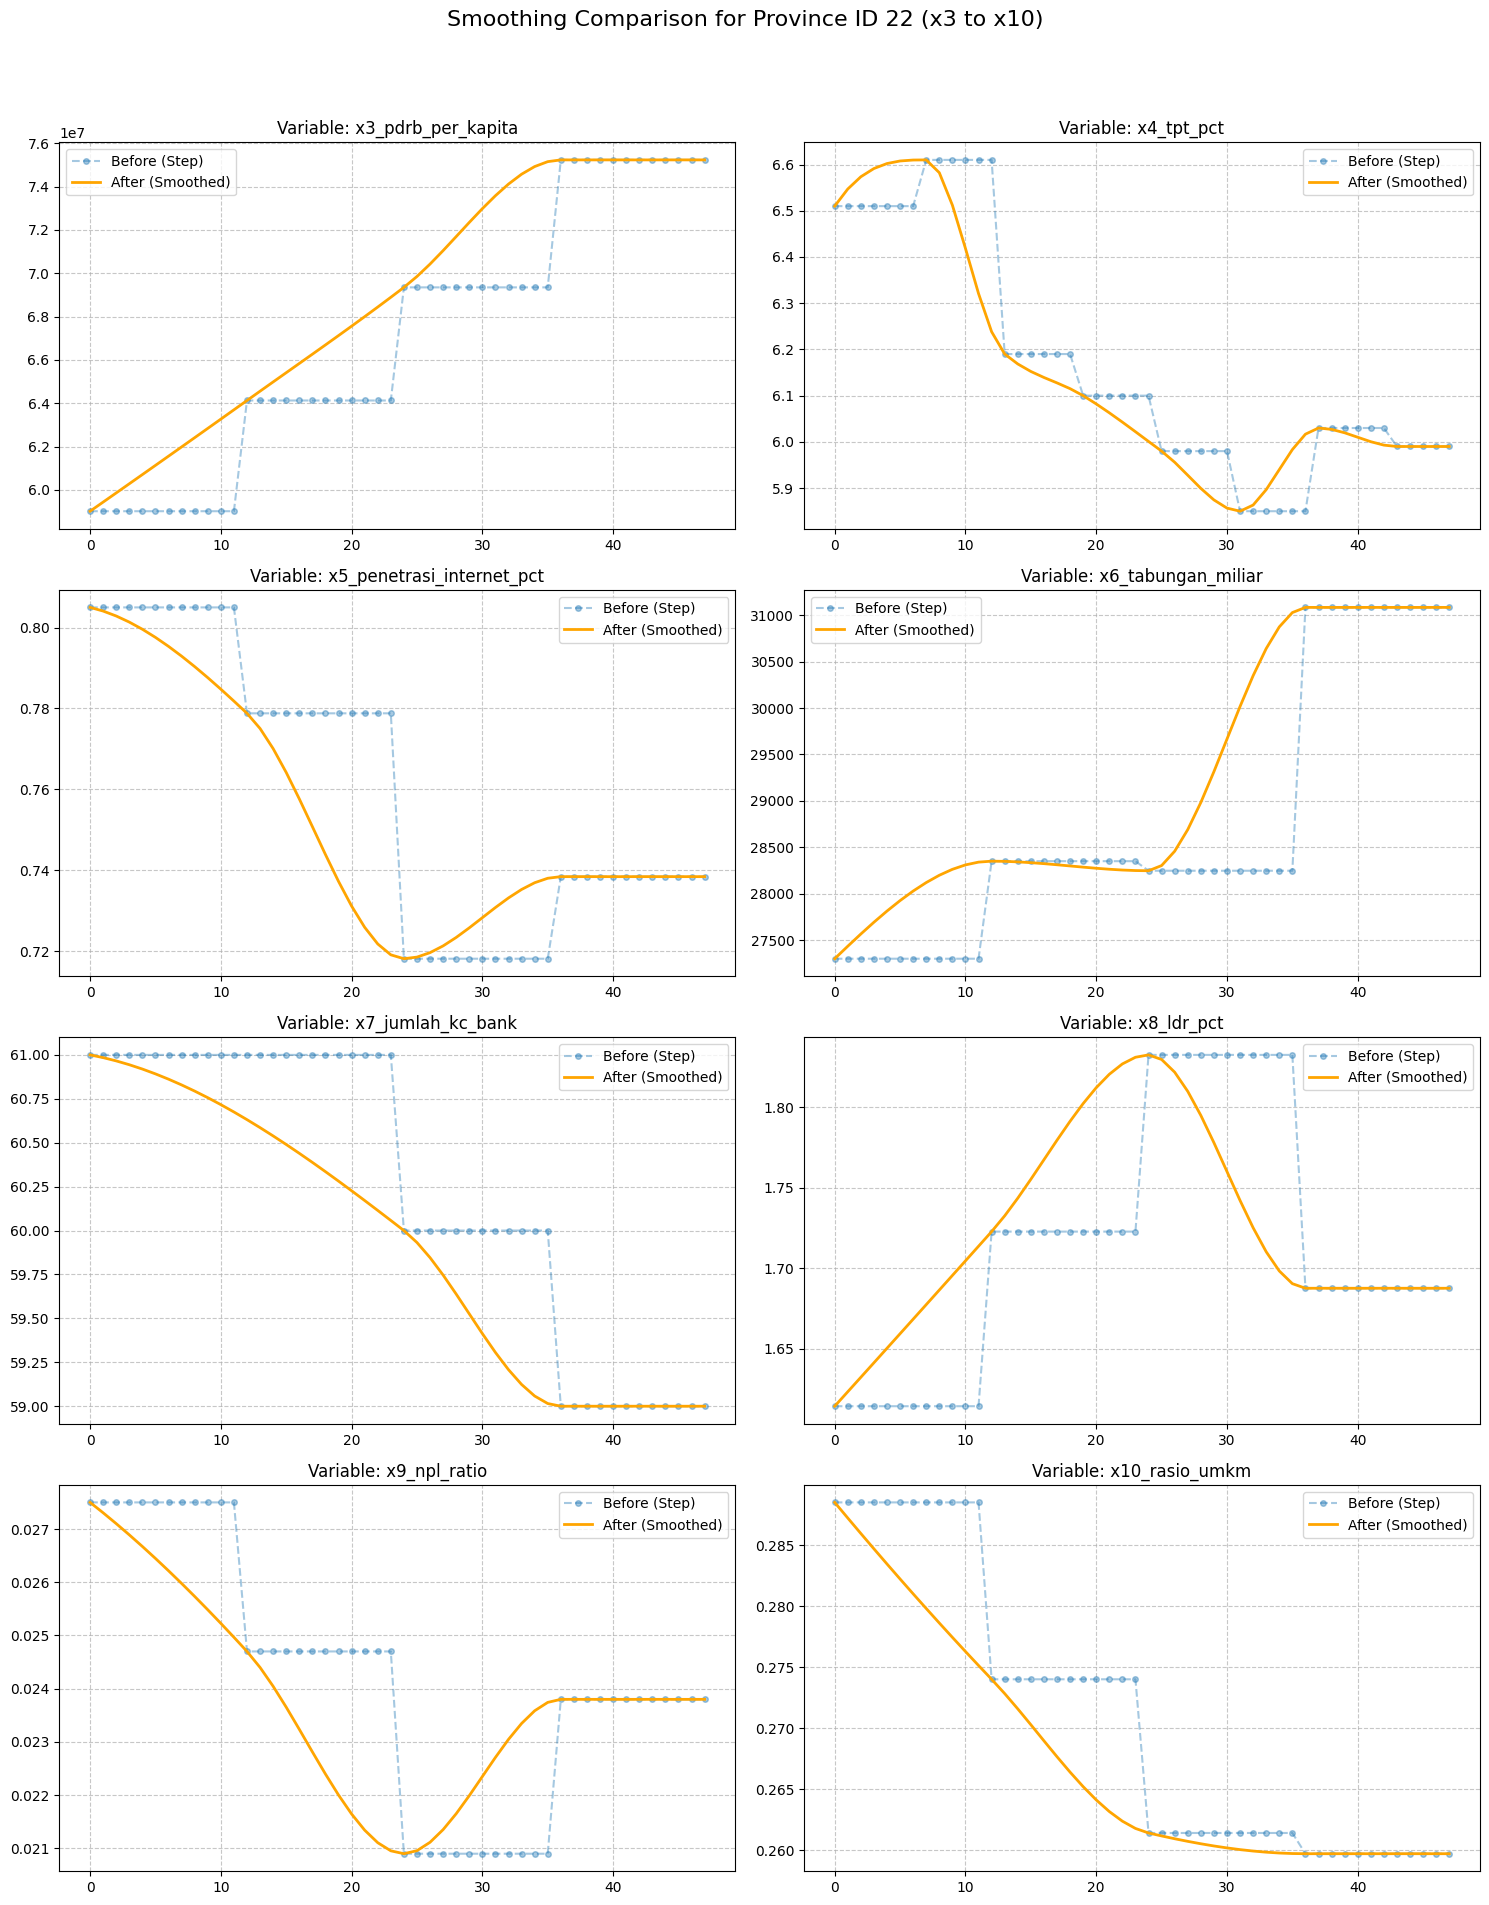

df_spline shape: (1536, 16)
Unique provinces after smoothing: 32


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# This block smooths the time series features so they are easier to interpret visually.
sticky_cols = ['x3_pdrb_per_kapita', 'x4_tpt_pct', 'x5_penetrasi_internet_pct',
               'x6_tabungan_miliar', 'x7_jumlah_kc_bank', 'x8_ldr_pct',
               'x9_npl_ratio', 'x10_rasio_umkm']

df_before = df_filtered.copy()

def apply_true_spline(group):
    # group.name stores the province id when using groupby().apply().
    province_id = group.name

    # Sort each province chronologically before smoothing.
    group = group.sort_values(['tahun', 'bulan']).copy()
    group['provinsi_id'] = province_id

    for col in sticky_cols:
        # Skip columns that are fully missing in a province.
        if group[col].isna().all():
            continue

        # Anchor points are values where the series changes; these keep the curve realistic.
        is_anchor = group[col] != group[col].shift(1)
        is_anchor.iloc[0] = True
        is_anchor.iloc[-1] = True

        series_with_nans = group[col].where(is_anchor, np.nan)
        group[col] = series_with_nans.interpolate(method='pchip')
        group[col] = group[col].ffill().bfill()

    return group

# Apply smoothing by province and keep the result flattened for later steps.
df_spline = df_before.groupby('provinsi_id', group_keys=False).apply(apply_true_spline).reset_index(drop=True)

# --- Visual comparison for one province ---
prov_id = 22
data_before = df_before[df_before['provinsi_id'] == prov_id].sort_values(['tahun', 'bulan'])
data_after = df_spline[df_spline['provinsi_id'] == prov_id].sort_values(['tahun', 'bulan'])

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
fig.suptitle(f'Smoothing Comparison for Province ID {prov_id} (x3 to x10)', fontsize=16)
axes = axes.flatten()

for i, col in enumerate(sticky_cols):
    axes[i].plot(range(len(data_before)), data_before[col], 'o--', label='Before (Step)', alpha=0.4, markersize=4)
    axes[i].plot(range(len(data_after)), data_after[col], '-', label='After (Smoothed)', linewidth=2, color='orange')
    axes[i].set_title(f'Variable: {col}')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"df_spline shape: {df_spline.shape}")
print(f"Unique provinces after smoothing: {df_spline['provinsi_id'].nunique()}")

## 6. Smoothing dengan PCHIP

Pada langkah ini kita merapikan seri waktu yang cenderung berbentuk tangga (stepwise). Metode PCHIP dipakai agar kurva tetap halus tanpa membuat lonjakan yang tidak realistis.

In [45]:
df_spline.info()

<class 'pandas.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   nama_provinsi              1536 non-null   str           
 1   tanggal                    1536 non-null   datetime64[us]
 2   tahun                      1536 non-null   int64         
 3   bulan                      1536 non-null   int64         
 4   twp90_pct                  1536 non-null   float64       
 5   x1_bi_rate_pct             1536 non-null   float64       
 6   x2_inflasi_yoy             1536 non-null   float64       
 7   x3_pdrb_per_kapita         1536 non-null   float64       
 8   x4_tpt_pct                 1536 non-null   float64       
 9   x5_penetrasi_internet_pct  1536 non-null   float64       
 10  x6_tabungan_miliar         1488 non-null   float64       
 11  x7_jumlah_kc_bank          1488 non-null   float64       
 12  x8_ldr_pct       

In [46]:
import pandas as pd

# df_spline contains the cleaned and smoothed panel.
df_lagged = df_spline.copy()

# Ensure the data is sorted before creating lag features.
df_lagged = df_lagged.sort_values(by=['provinsi_id', 'tanggal']).reset_index(drop=True)

# Select all base feature columns that start with x.
base_x_features = [col for col in df_lagged.columns if col.startswith('x') and '_lag_' not in col]

# Fill residual missing values in base features first.
# We use province-wise forward/backward fill, then fall back to the column median.
for feature in base_x_features:
    df_lagged[feature] = df_lagged.groupby('provinsi_id')[feature].transform(lambda s: s.ffill().bfill())
    if df_lagged[feature].isna().any():
        df_lagged[feature] = df_lagged[feature].fillna(df_lagged[feature].median())

# Create 3-month and 6-month lag features for each province separately.
lags = [3, 6]
for lag in lags:
    for feature in base_x_features:
        new_col_name = f"{feature}_lag_{lag}"
        df_lagged[new_col_name] = df_lagged.groupby('provinsi_id')[feature].transform(lambda s, lag=lag: s.shift(lag))

# Report missing values after lag creation.
lag_cols = [col for col in df_lagged.columns if '_lag_' in col]
print("--- Laporan Missing Values Pasca-Lagging ---")
print(df_lagged[lag_cols].isnull().sum().sort_values(ascending=False).head(10))
print(f"Total baris awal: {len(df_lagged)}")
df_lagged.info()

--- Laporan Missing Values Pasca-Lagging ---
x7_jumlah_kc_bank_lag_6            192
x8_ldr_pct_lag_6                   192
x2_inflasi_yoy_lag_6               192
x1_bi_rate_pct_lag_6               192
x9_npl_ratio_lag_6                 192
x10_rasio_umkm_lag_6               192
x4_tpt_pct_lag_6                   192
x3_pdrb_per_kapita_lag_6           192
x6_tabungan_miliar_lag_6           192
x5_penetrasi_internet_pct_lag_6    192
dtype: int64
Total baris awal: 1536
<class 'pandas.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 36 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   nama_provinsi                    1536 non-null   str           
 1   tanggal                          1536 non-null   datetime64[us]
 2   tahun                            1536 non-null   int64         
 3   bulan                            1536 non-null   int64         
 4   twp90_pct     

## 7. Membuat fitur lag

Fitur lag membantu model melihat pengaruh kondisi 3 bulan dan 6 bulan sebelumnya. Ini penting untuk data ekonomi yang biasanya punya efek tertunda.

## 8. Menyiapkan data untuk modeling

Sebelum model dilatih, kita pastikan fitur utama sudah bersih dan cukup lengkap. Di sini kita mengurangi missing value yang tersisa, lalu menyiapkan split train/test dengan aman agar tidak menghasilkan dataset kosong.

In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Try to use XGBoost, but keep a fallback so the notebook still runs if it is unavailable.
try:
    import xgboost as xgb
    model_name = "XGBoost"
    use_xgboost = True
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    model_name = "RandomForest"
    use_xgboost = False

# 1. Prepare modeling data more safely.
# We keep rows that have the target and the lag features, then avoid dropping the entire dataset because of unrelated NaNs.
lag_columns = [col for col in df_lagged.columns if '_lag_' in col]
model_required_cols = lag_columns + ['twp90_pct']
df_model = df_lagged.dropna(subset=model_required_cols).copy()

# Ensure year is numeric so the temporal split works reliably.
df_model['tahun'] = pd.to_numeric(df_model['tahun'], errors='coerce')
df_model = df_model.dropna(subset=['tahun'])
df_model['tahun'] = df_model['tahun'].astype(int)

# 2. Define predictors (X) and target (y).
# We exclude identity/time columns and keep both base features and lag features.
kolom_non_prediktor = ['provinsi_id', 'nama_provinsi', 'tanggal', 'tahun', 'bulan', 'twp90_pct']
X_cols = [col for col in df_model.columns if col not in kolom_non_prediktor]

print(f"Total rows available for modeling: {len(df_model):,}")
print(f"Total features used: {len(X_cols)}")

# 3. Temporal split (based on year).
# Train: 2022-2024 | Test: 2025
train_data = df_model[df_model['tahun'] <= 2024].copy()
test_data = df_model[df_model['tahun'] == 2025].copy()

# If the strict split is empty for any reason, fall back to an 80/20 time-ordered split.
if train_data.empty or test_data.empty:
    print("Warning: strict temporal split produced an empty set. Using 80/20 chronological fallback split.")
    df_model = df_model.sort_values('tanggal').reset_index(drop=True)
    split_idx = int(0.8 * len(df_model))
    train_data = df_model.iloc[:split_idx].copy()
    test_data = df_model.iloc[split_idx:].copy()

X_train = train_data[X_cols]
y_train = train_data['twp90_pct']
X_test = test_data[X_cols]
y_test = test_data['twp90_pct']

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

if X_train.empty or X_test.empty:
    raise ValueError("Data modeling masih kosong setelah preprocessing. Cek imputasi, lag features, dan filter tahun.")

# 4. Train the baseline model.
if use_xgboost:
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )
else:
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

# 5. Prediction and evaluation.
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Evaluasi Baseline Model ({model_name}) ---")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# 6. Feature importance (if the model supports it).
if hasattr(model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': X_cols,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    print("\n--- Top 15 Fitur Paling Berpengaruh ---")
    print(importance.head(15))
else:
    importance = pd.DataFrame({'Feature': X_cols, 'Importance': np.nan})
    print("\nModel ini tidak menyediakan feature_importances_.")

Total rows available for modeling: 1,344
Total features used: 30
Dimensi X_train: (960, 30)
Dimensi X_test: (384, 30)

--- Evaluasi Baseline Model (XGBoost) ---
RMSE: 0.0081
MAE: 0.0040
R-squared (R2): 0.4579

--- Top 15 Fitur Paling Berpengaruh ---
                            Feature  Importance
7                        x8_ldr_pct    0.328404
6                 x7_jumlah_kc_bank    0.154668
5                x6_tabungan_miliar    0.145703
28               x9_npl_ratio_lag_6    0.039950
13                 x4_tpt_pct_lag_3    0.036771
0                    x1_bi_rate_pct    0.029545
22         x3_pdrb_per_kapita_lag_6    0.027543
9                    x10_rasio_umkm    0.020882
2                x3_pdrb_per_kapita    0.019066
23                 x4_tpt_pct_lag_6    0.018029
27                 x8_ldr_pct_lag_6    0.015988
24  x5_penetrasi_internet_pct_lag_6    0.014789
8                      x9_npl_ratio    0.014381
18               x9_npl_ratio_lag_3    0.014289
29             x10_rasio_umkm_

## 9. Melatih model baseline

Di langkah ini kita melatih model awal untuk melihat seberapa baik fitur-fitur yang sudah dibentuk dalam menjelaskan target. Hasilnya dipakai sebagai acuan sebelum melakukan penyempurnaan model.

In [48]:
from pathlib import Path
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Kunci 15 Fitur Terbaik
# Model disederhanakan menggunakan fitur yang paling berpengaruh dari cell sebelumnya.
top_15_features = importance.head(15)['Feature'].tolist()

X_train_final = X_train[top_15_features]
X_test_final = X_test[top_15_features]

# 2. Latih Model Final (Parameter Default XGBoost)
final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

final_model.fit(X_train_final, y_train)

# 3. Evaluasi Akhir
y_pred_final = final_model.predict(X_test_final)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final = mean_absolute_error(y_test, y_pred_final)
r2_final = r2_score(y_test, y_pred_final)

print("\n--- PERFORMA MODEL FINAL ---")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE: {mae_final:.4f}")
print(f"R-squared (R2): {r2_final:.4f}")

# 4. Simpan model ke folder workspace lokal
save_path = Path('xgb_twp90_final.json')
final_model.save_model(str(save_path))
print(f"Model saved to: {save_path.resolve()}")


--- PERFORMA MODEL FINAL ---
RMSE: 0.0082
MAE: 0.0041
R-squared (R2): 0.4352
Model saved to: C:\Users\bimyu\Documents\Projects\DatathonMETC\xgb_twp90_final.json


## 10. Menyempurnakan model

Setelah fitur penting ditemukan, model dilatih ulang menggunakan fitur terbaik saja untuk melihat apakah performa bisa ditingkatkan atau justru lebih stabil.

### Visual Proof: The Domino Effect
This chart visualizes the relationship between conventional bank credit quality (`x9_npl_ratio`) and P2P lending defaults (`twp90_pct`). By shifting the NPL line forward by 6 months, we can see how historical bank data leads P2P outcomes.

## 11. Visualisasi hubungan antar variabel

Bagian terakhir menampilkan visual proof untuk membantu membaca hubungan antara kualitas kredit bank konvensional dan default P2P yang diamati beberapa bulan kemudian.

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose one representative province to illustrate the relationship visually.
prov_id_demo = 1

data_demo = df_filtered[df_filtered['provinsi_id'] == prov_id_demo].sort_values('tanggal').copy()

fig, ax1 = plt.subplots(figsize=(14, 7))

# Primary axis: the target variable (TWP90).
color_twp = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('TWP90 (%)', color=color_twp, fontweight='bold')
ax1.plot(data_demo['tanggal'], data_demo['twp90_pct'], color=color_twp, linewidth=3, label='TWP90 (Actual)')
ax1.tick_params(axis='y', labelcolor=color_twp)

# Secondary axis: NPL ratio shifted 6 months forward as a leading indicator.
ax2 = ax1.twinx()
color_npl = 'tab:blue'
ax2.set_ylabel('NPL Ratio (Shifted +6m)', color=color_npl, fontweight='bold')
data_demo['tanggal_shifted'] = data_demo['tanggal'] + pd.DateOffset(months=6)
ax2.plot(data_demo['tanggal_shifted'], data_demo['x9_npl_ratio'], color=color_npl,
         linestyle='--', linewidth=2, alpha=0.7, label='NPL (Leading Indicator - 6m ago)')
ax2.tick_params(axis='y', labelcolor=color_npl)

plt.title(f'The Domino Effect: How Bank NPL Leads P2P Defaults (Province {prov_id_demo})', fontsize=14)
fig.tight_layout()

# Combine legends from both axes so the chart is easier to interpret.
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.grid(True, alpha=0.3)
plt.show()

ModuleNotFoundError: No module named 'seaborn'